In [1]:
import numpy as np
# 1. Numpy Arrays
# Compute the following using Python NumPy array data structure.
# Reverse the array with values ranging from 12 to 38. <- 38 inclusive?
ar = np.arange(12, 39)
ar_rev = np.sort(ar) # reverse it here
print(f"the reversed array is: {ar_rev}")

the reversed array is: [12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35
 36 37 38]


In [2]:
# Compute the inverse of 
A = np.random.randint(10, size=(3, 3))
inverse = np.linalg.inv(A) # <- this kind of inverse?
print(f"this is the inverse: {inverse}")

this is the inverse: [[-0.16788321  0.17518248  0.10948905]
 [ 0.1459854  -0.02189781 -0.13868613]
 [ 0.05839416 -0.07542579  0.07785888]]


In [3]:
# Create a 2D array with 1 on the border and 0 inside. Add a border filled with 0s around the existing array.
# a 2D array is a matrix 
rows = 3
columns = 3
arr = np.ones((rows, columns)).astype(np.int32)
surrounding = np.zeros((rows + 2, columns + 2)).astype(np.int32)

def replace_center(array):
    dimensions = array.shape
    rows = dimensions[0]
    columns = dimensions[1]
    tmp = array.flatten()
    size = tmp.size
    print(f"size of the array is {size}")
    for i in range(size):
        #print(i)
        if ((i == size // 2) or (i == size/2 + 1) or (i == size/2 - 1)):
            #print("true")
            if (tmp[i] == 1):
                tmp[i] = 0
            else:
                tmp[i] = 1
    print(type(tmp))
    tmp = tmp.reshape(rows, columns)
    return tmp

def surround(array):
    dimensions = array.shape
    rows = dimensions[0]
    columns = dimensions[1]
    # create top and bottom arrays that will be vertically added at the end
    top = np.zeros((1, columns+2)).astype(np.int32)
    bottom = top
    if (array[0][0] == 1): # first element is one
        prepend = np.array([[0]]).astype(np.int32)
    else:
        prepend = np.array([[1]]).astype(np.int32)
    # go through each array and append the array to prepend
    #center 
    tmp1 = np.append(prepend, array.flatten()[:rows]) # leading zero/one, flattens array
    tmp2 = np.append(tmp1, prepend) # trailing zero/one
    fin = np.vstack((top,tmp2)) 
    for i in range(rows-1):
        fin = np.vstack((fin,tmp2))
    fin = np.vstack((fin, bottom))    
    return fin
    

print(arr)
#print(surrounding)
print(arr.dtype)
replace_center(surround(arr))


[[1 1 1]
 [1 1 1]
 [1 1 1]]
int32
size of the array is 25
<class 'numpy.ndarray'>


array([[0, 0, 0, 0, 0],
       [0, 1, 1, 1, 0],
       [0, 1, 0, 1, 0],
       [0, 1, 1, 1, 0],
       [0, 0, 0, 0, 0]], dtype=int32)

In [4]:
# Find the k smallest values in the array [2, 7.9, 8, 1.5, 4, 14, 3.5, 1.45, 3.5, 6].
# I can partition it first then sort, all using k
k = 3
smallest_k = np.array([2, 7.9, 8, 1.5, 4, 14, 3.5, 1.45, 3.5, 6])
smallest_k = np.partition(smallest_k, k)
smallest_k_filtered = np.sort(smallest_k[:k])
#print(smallest_k)
print(smallest_k_filtered)

[1.45 1.5  2.  ]


In [5]:
# Rank items in C = np.random.randint(30, size=(3, 5)). Generate the rank array. [HINT: ravel(), argsort(), reshape()]
C = np.random.randint(30, size=(3, 5))

C_flat = np.ravel(C)
order = np.argsort(C_flat)
ranks = np.empty_like(order)
ranks[order] = np.arange(len(C_flat))
rank_array = ranks.reshape(C.shape)


print(f"The original array is: {C}")
print(f"The ranks for array C are:{rank_array}")

The original array is: [[17 13 25 28 25]
 [13  5  7 14  9]
 [ 1 12 23  7 16]]
The ranks for array C are:[[10  6 12 14 13]
 [ 7  1  2  8  4]
 [ 0  5 11  3  9]]


In [6]:
# Create an array with 10 numbers, and apply a boolean mask to filter every other value.
import numpy.ma as ma
# every other value will be even
ten_nums = np.arange(0,10)
mask = ten_nums % 2 == 0
filtered = ten_nums[mask] # gives me the array instead of indices, using fancy indexing
print(ten_nums)
print(filtered)
    

[0 1 2 3 4 5 6 7 8 9]
[0 2 4 6 8]


In [7]:
# 2. Exploratory Data analysis
# The Stanford Open Policing ProjectLinks to an external site. is collecting and standardizing data on vehicle and pedestrian stops from law enforcement 
# departments across the country. They've collected data from 31 US states. You will use the data from the state of Rhode Island. 
# Download the datasets police.csv and weather.csv You will explore and analyze the impact of gender on police behavior. 
# This will involve cleaning messy data, combining and reshaping datasets, and manipulating time series data.
import pandas as pd

# 2.1 Prepping data

# Load police.csv and weather.csv datasets to pandas dataframes, outcomes and weather.
outcomes = pd.read_csv('police.csv')
police_shape_og = outcomes.shape
weather = pd.read_csv('weather.csv')
weather_shape_og = weather.shape


# Locate missing values

# Drop columns and rows (based on missing value counts) [HINT: .isnull().sum()]

def remove_missing(df):
    rows_drop = df.index[df.isnull().sum(axis=1) > 50] # row, 5 empty values in the row
    columns_drop = df.columns[df.isnull().sum(axis=0) > 10000] # column, more than 10000 empty values

    df = df.drop(columns = columns_drop)
    df = df.drop(index = rows_drop)
    return df

#weather = remove_missing(weather)
#outcomes = remove_missing(outcomes)

w_shape = remove_missing(weather).shape
p_shape = remove_missing(outcomes).shape


# Examine shape with fewer rows and columns [HINT: specify the rows/columns you have dropped)
def show_diff(df):
    columns_dropped = df.columns.difference(remove_missing(df).columns)
    print("Dropped columns:", columns_dropped)
    
print(f"The original shape of the police csv was {police_shape_og}, while the cleaned shape is {p_shape}")
print(f"The original shape of the weather csv was {weather_shape_og}, while the cleaned shape is {w_shape}")

show_diff(outcomes)
show_diff(weather)

"""
remove missing still cleans outcomes
but not weather
need to fix the range
"""
weather = remove_missing(weather)
outcomes = remove_missing(outcomes)


# Examine and fix incorrect data types
#print(weather.dtypes) # what would be an incorrect datatype??
weather['date'] = pd.to_datetime(weather['DATE'])
weather = weather.set_index('date')

# Combine date and time columns to create a Datetime index.
outcomes['datetime'] = pd.to_datetime(outcomes['stop_date'] + ' ' + outcomes['stop_time'])

outcomes = outcomes.set_index('datetime') # have to set this or resampling won't work
outcomes


The original shape of the police csv was (91741, 15), while the cleaned shape is (91741, 13)
The original shape of the weather csv was (4017, 27), while the cleaned shape is (4017, 27)
Dropped columns: Index(['county_name', 'search_type'], dtype='object')
Dropped columns: Index([], dtype='object')


,state,stop_date,stop_time,driver_gender,driver_race,violation_raw,violation,search_conducted,stop_outcome,is_arrested,stop_duration,drugs_related_stop,district
datetime,,,,,,,,,,,,,
2005-01-04 12:55:00,RI,2005-01-04,12:55,M,White,Equipment/Inspection Violation,Equipment,False,Citation,False,0-15 Min,False,Zone X4
2005-01-23 23:15:00,RI,2005-01-23,23:15,M,White,Speeding,Speeding,False,Citation,False,0-15 Min,False,Zone K3
2005-02-17 04:15:00,RI,2005-02-17,04:15,M,White,Speeding,Speeding,False,Citation,False,0-15 Min,False,Zone X4
2005-02-20 17:15:00,RI,2005-02-20,17:15,M,White,Call for Service,Other,False,Arrest Driver,True,16-30 Min,False,Zone X1
2005-02-24 01:20:00,RI,2005-02-24,01:20,F,White,Speeding,Speeding,False,Citation,False,0-15 Min,False,Zone X3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-12-31 21:21:00,RI,2015-12-31,21:21,F,Black,Other Traffic Violation,Moving violation,False,Citation,False,0-15 Min,False,Zone K2
2015-12-31 21:59:00,RI,2015-12-31,21:59,F,White,Speeding,Speeding,False,Citation,False,0-15 Min,False,Zone K3
2015-12-31 22:04:00,RI,2015-12-31,22:04,M,White,Other Traffic Violation,Moving violation,False,Citation,False,0-15 Min,False,Zone X3


In [8]:
# 2.2 Examination - Examining traffic violations using outcomes

# Count the unique values in violations. Express counts as proportions.
# i can use the count_values method
print(f"{outcomes.value_counts('violation', normalize=True)}\n") # normalize=True gives the proportion
#print(type(outcomes.value_counts('violation'))) # output is a pandas series

# Compare violations by gender.
mask_male = outcomes['driver_gender'] == 'M'
mask_female = outcomes['driver_gender'] == 'F'
print(f"violations by men:\n{outcomes[mask_male].value_counts('violation')} \n")
print(f"violations by women:\n{outcomes[mask_female].value_counts('violation')} \n")

# Compare stop outcomes by gender.
print(f"stop outcomes for men:\n{outcomes[mask_male].value_counts('stop_outcome')} \n")
print(f"stop outcomes for women:\n{outcomes[mask_female].value_counts('stop_outcome')} \n")

# Compare the rate of annual drug-related stops for each year. What is the observed pattern. [HINT: .resample('A').mean()]
#print(type(outcomes.index))
drug = outcomes['drugs_related_stop'].resample('YE').mean() # 'A' is deprecated, says to use 'YE'
print(f"rate of annual drug-related stops:\n{drug}")

# Tally violations by district [HINT: pd.crosstab]
dist_violation = pd.crosstab(outcomes['district'], outcomes['violation'])
print(f"violations by district:\n{dist_violation}")

violation
Speeding               0.559563
Moving violation       0.187476
Equipment              0.126209
Other                  0.050960
Registration/plates    0.042790
Seat belt              0.033002
Name: proportion, dtype: float64

violations by men:
violation
Speeding               32777
Moving violation       12938
Equipment               8420
Other                   3702
Registration/plates     2647
Seat belt               2278
Name: count, dtype: int64 

violations by women:
violation
Speeding               15646
Moving violation        3286
Equipment               2501
Registration/plates     1056
Other                    707
Seat belt                578
Name: count, dtype: int64 

stop outcomes for men:
stop_outcome
Citation            55840
Warning              3651
Arrest Driver        2179
N/D                   439
No Action             423
Arrest Passenger      230
Name: count, dtype: int64 

stop outcomes for women:
stop_outcome
Citation            21251
Warning         

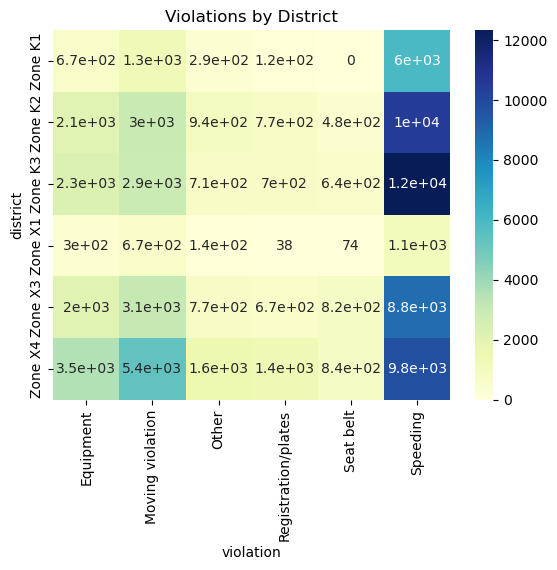

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# for crosstab - Heatmap
sns.heatmap(dist_violation ,annot=True, cmap='YlGnBu')
plt.title('Violations by District')
plt.show()

In [10]:
# 2.3 Count the number of bad weather conditions each day.

# Calculate the sum of rows in the WT? columns and save it as a new column 'bad_conditions'. 
# Replace the missing values in 'bad_conditions' with 0.

WT = weather.loc[:, 'WT01':'WT22'] # locate just the WT values for all rows\\
weather.loc[:, 'WT01':'WT22'] = WT.isnull().fillna(0).astype('int') # replace the NaN values with zeroes
weather['bad_conditions'] = weather.loc[:, 'WT01':'WT22'].sum(axis='columns') # sum the axes, save as bad_conditions
#print(f"the modified weather conditions:\n{weather}")

# Use the counts to create a rating system for the weather. [HINT: Use .map() to map values to rating categories]. Save it as a new column 'rating'.
# Convert 0 to 'good'
# Convert 1 through 4 to 'bad'
# Convert 5 through 9 to 'worse'
# [HINT: mapping = { 0:'good', ..... }
mapping = {**{0: 'good'}, 
           **dict.fromkeys(range(1, 5), 'bad'), 
           **dict.fromkeys(range(5, 10), 'worse')} # this is just easier to create the range

weather['rating'] = weather['bad_conditions'].map(mapping) # map the values to the ranges in a new column
weather

# Change the data type to category and specify the logical order: 'good', 'bad', 'worse'. 
categories = pd.CategoricalDtype(['good', 'bad', 'worse'], ordered=True)
weather['rating'] = weather.loc[:, 'rating'].astype(categories) 
weather

# Extract the date and rating columns from the weather dataframe to a new dataframe weather_rating.
date = weather.loc[:, 'DATE'] # i dont really need this as the index is already based on the date...
# i need the above for the next part
ratings = weather.loc[:,'rating']
df = {'DATE': date, 'rating': ratings}
weather_rating = pd.DataFrame(df)
weather_rating

#weather


,DATE,rating
date,,
2005-01-01,2005-01-01,NaN
2005-01-02,2005-01-02,NaN
2005-01-03,2005-01-03,NaN
2005-01-04,2005-01-04,NaN
2005-01-05,2005-01-05,NaN
...,...,...
2015-12-27,2015-12-27,NaN
2015-12-28,2015-12-28,NaN
2015-12-29,2015-12-29,NaN


In [35]:
# Compare arrest rates by weather rating.

# Merge the outcomes and weather_rating dataframes as outcomes_weather. 
# [HINT: left=outcomes, right=weather_rating, left_on='stop_date', right_on='DATE', how='left']
outcomes_weather = pd.merge(outcomes, weather_rating, left_on='stop_date', right_on='DATE', how='left')
outcomes_weather
# im going to make DATE the index
#mask_rating = outcomes_weather['rating'] == 'bad'
# print(outcomes_weather[mask_rating])
outcomes_weather['datetime'] = pd.to_datetime(outcomes_weather['DATE'] + ' ' + outcomes_weather['stop_time'])
# Calculate arrest rate for each of the weather settings, add violation as a second factor in the analysis, to account for differences in the arrest rate. [HINT: arrest_rate = ______.groupby(['violation', 'rating']).is_arrested.mean()].
outcomes_weather.set_index(outcomes_weather['datetime'],inplace=True)
outcomes_weather.drop(['DATE'],axis=1, inplace=True) # getting rid of the redundant date column
outcomes_weather.drop(['datetime'],axis=1, inplace=True)
#outcomes_weather

# Compute overall arrest rate.
arrest_rate = outcomes_weather.value_counts('is_arrested', normalize=True)

# Reshape the arrest rate data: Unstack the arrest_rate series to reshape it into a dataframe.
# my index is not stacked?...
print(type(arrest_rate))
arrest_rate_df = pd.DataFrame([arrest_rate])
arrest_rate_df.reset_index()
arrest_rate_df.columns = ['Not_arrested', 'Arrested']

# Create the same dataframe using a pivot table.
arrest_rate_pivot = pd.pivot_table(
    pd.DataFrame([arrest_rate]), 
    index=None,
    columns='is_arrested'
)

def display_attr(df):
      print(type(df))
      print(df.index)
      print(f"{df.columns}\n")

display_attr(arrest_rate_pivot)
display_attr(arrest_rate_df)

print(list(arrest_rate_df['Not_arrested'].values) + list(arrest_rate_df['Arrested'].values))
print(list(arrest_rate_df.columns))

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>
Index([False, True], dtype='bool', name='is_arrested')
Index(['is_arrested'], dtype='object')

<class 'pandas.core.frame.DataFrame'>
Index(['proportion'], dtype='object')
Index(['Not_arrested', 'Arrested'], dtype='object')

[np.float64(0.964432221310623), np.float64(0.03556777868937704)]
['Not_arrested', 'Arrested']


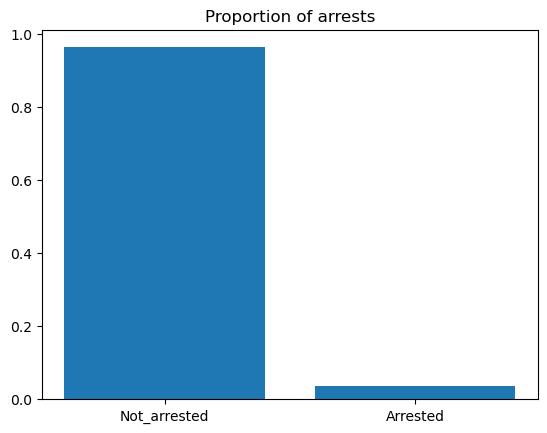

In [38]:
# proportion of arrest rate
fig = plt.figure()
ax1 = fig.add_subplot()
ax1.bar(list(arrest_rate_df.columns), list(arrest_rate_df['Not_arrested'].values) + list(arrest_rate_df['Arrested'].values))
plt.title('Proportion of arrests')
plt.show()
